In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

master = pd.read_csv(
    "../data/processed/tourism_master_cleaned.csv"
)

print("Dataset shape:", master.shape)
display(master.head())

Dataset shape: (52930, 27)


,transactionid,userid,visityear,visitmonth,visitmode,attractionid,rating,user_continentid,user_regionid,user_countryid,user_cityid,user_cityname,user_city_countryid,user_country,user_country_regionid,user_region,user_region_continentid,user_continent,attractioncityid,attractiontypeid,attraction,attractionaddress,attractiontype,attraction_cityname,attraction_countryid,attraction_country,attraction_regionid
0,3,70456,2022,10,2,640,5,5,21,163,4341.0,Guildford,109.0,United Kingdom,21,Western Europe,5,Europe,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,1,Cameroon,1
1,8,7567,2022,10,4,640,5,2,8,48,464.0,Ontario,48.0,Canada,8,Northern America,2,America,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,1,Cameroon,1
2,9,79069,2022,10,3,640,5,2,9,54,774.0,Brazil,51.0,Brazil,9,South America,2,America,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,1,Cameroon,1
3,10,31019,2022,10,3,640,3,5,17,135,583.0,Zurich,48.0,Switzerland,17,Central Europe,5,Europe,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,1,Cameroon,1
4,15,43611,2022,10,2,640,3,5,21,163,1396.0,Manchester,51.0,United Kingdom,21,Western Europe,5,Europe,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia",Nature & Wildlife Areas,Douala,1,Cameroon,1


In [51]:
master.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
transactionid,52930.0,NaN,NaN,NaN,70415.130474,66299.514206,3.0,19646.25,42770.5,105638.75,211241.0
userid,52930.0,NaN,NaN,NaN,45024.522596,25073.062199,14.0,23470.0,45533.5,66667.0,88190.0
visityear,52930.0,NaN,NaN,NaN,2016.351899,1.732926,2013.0,2015.0,2016.0,2018.0,2022.0
visitmonth,52930.0,NaN,NaN,NaN,6.6331,3.392979,1.0,4.0,7.0,9.0,12.0
visitmode,52930.0,NaN,NaN,NaN,2.945759,1.000683,1.0,2.0,3.0,4.0,5.0
attractionid,52930.0,NaN,NaN,NaN,759.663782,210.716111,369.0,640.0,737.0,841.0,1297.0
rating,52930.0,NaN,NaN,NaN,4.157699,0.970543,1.0,4.0,4.0,5.0,5.0
user_continentid,52930.0,NaN,NaN,NaN,3.592877,1.075526,1.0,3.0,4.0,5.0,5.0
user_regionid,52930.0,NaN,NaN,NaN,14.524353,4.186649,0.0,13.0,15.0,17.0,21.0
user_countryid,52930.0,NaN,NaN,NaN,106.297657,35.738949,1.0,93.0,109.0,121.0,164.0


In [52]:
print("Number of users:", master["userid"].nunique())
print("Number of transactions:", master["transactionid"].nunique())
print("Number of attractions:", master["attractionid"].nunique())
print("Number of cities:", master["attractioncityid"].nunique())

Number of users: 33530
Number of transactions: 52930
Number of attractions: 30
Number of cities: 3


In [53]:
rating_counts = master["rating"].value_counts().sort_index()

print(rating_counts)

rating
1     1263
2     2035
3     7730
4    17966
5    23936
Name: count, dtype: int64


✅ EDA summary tables saved.
Removed duplicate columns:
[]

New shape: (52930, 27)
['transactionid', 'userid', 'visityear', 'visitmonth', 'visitmode', 'attractionid', 'rating', 'user_continentid', 'user_regionid', 'user_countryid', 'user_cityid', 'user_cityname', 'user_city_countryid', 'user_country', 'user_country_regionid', 'user_region', 'user_region_continentid', 'user_continent', 'attractioncityid', 'attractiontypeid', 'attraction', 'attractionaddress', 'attractiontype', 'attraction_cityname', 'attraction_countryid', 'attraction_country', 'attraction_regionid']
✅ Final EDA-clean dataset saved.


,user_country,visitors,transactions,average_rating
7,Australia,8848,13322,4.219712
144,United Kingdom,4062,6722,4.164088
145,United States,3799,6261,4.160837
62,Indonesia,2889,4842,4.265386
122,Singapore,1815,2807,4.027075
61,India,1627,2543,4.208022
81,Malaysia,919,1581,4.029096
27,Canada,916,1486,4.186406
100,New Zealand,959,1479,4.148749
98,Netherlands,570,859,3.910361


,user_region,visitors,transactions,average_rating
1,Australia,8848,13322,4.219712
17,South East Asia,6387,10392,4.134527
21,Western Europe,5275,8534,4.123272
12,Northern America,4788,7847,4.167580
16,South Asia,1858,2874,4.218859
6,Central Europe,1421,2309,4.107839
14,Oceania,989,1530,4.149020
10,Middle East,835,1266,4.242496
8,East Asia,718,1121,4.094558
19,Southern Europe,637,990,4.098990


,user_continent,visitors,transactions,average_rating
2,Asia,9822,15693,4.155738
3,Australia & Oceania,9837,14852,4.212429
4,Europe,8260,13278,4.100090
1,America,5018,8187,4.163430
0,Africa,593,920,4.088043


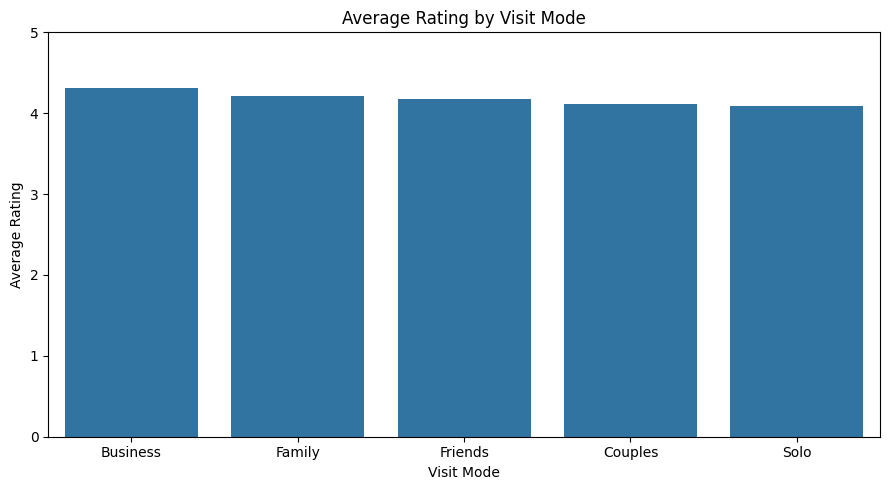

In [54]:
import os
import seaborn as sns

import matplotlib.pyplot as plt

# Ensure output directory exists
os.makedirs("../reports/eda", exist_ok=True)

# Save EDA summary tables
rating_counts.to_csv("../reports/eda/rating_distribution.csv")
mode_counts.to_csv("../reports/eda/visit_mode_distribution.csv")
attraction_popularity.to_csv("../reports/eda/attraction_popularity.csv", index=False)
attraction_ratings.to_csv("../reports/eda/attraction_ratings.csv", index=False)
type_analysis.to_csv("../reports/eda/attraction_type_analysis.csv", index=False)

print("✅ EDA summary tables saved.")

# Remove duplicate columns if present
duplicate_columns = [
    "attraction_region_x",
    "attraction_region_y",
    "attraction_continentid_x",
    "attraction_continentid_y",
]
duplicate_columns = [col for col in duplicate_columns if col in master.columns]

master = master.drop(columns=duplicate_columns)

print("Removed duplicate columns:")
print(duplicate_columns)
print("\nNew shape:", master.shape)

print(master.columns.tolist())

# Save cleaned master dataset
master.to_csv("../data/processed/tourism_master_cleaned.csv", index=False)
print("✅ Final EDA-clean dataset saved.")

# Country-level analysis
country_analysis = (
    master.groupby("user_country", observed=True)
    .agg(
        visitors=("userid", "nunique"),
        transactions=("transactionid", "count"),
        average_rating=("rating", "mean"),
    )
    .reset_index()
    .sort_values("transactions", ascending=False)
)
display(country_analysis.head(15))

# Region-level analysis
region_analysis = (
    master.groupby("user_region", observed=True)
    .agg(
        visitors=("userid", "nunique"),
        transactions=("transactionid", "count"),
        average_rating=("rating", "mean"),
    )
    .reset_index()
    .sort_values("transactions", ascending=False)
)
display(region_analysis)

# Continent-level analysis
continent_analysis = (
    master.groupby("user_continent", observed=True)
    .agg(
        visitors=("userid", "nunique"),
        transactions=("transactionid", "count"),
        average_rating=("rating", "mean"),
    )
    .reset_index()
    .sort_values("transactions", ascending=False)
)
display(continent_analysis)

# Plot: average rating by visit mode
plt.figure(figsize=(9, 5))
sns.barplot(
    data=rating_by_mode.reset_index(),
    x="visitmode_name",
    y="mean",
)

plt.title("Average Rating by Visit Mode")
plt.xlabel("Visit Mode")
plt.ylabel("Average Rating")
plt.ylim(0, 5)
plt.tight_layout()
plt.show()


In [55]:
mode_counts = (
    master.assign(visitmode_name=master["visitmode"].map(visitmode_labels))
    ["visitmode_name"]
    .value_counts()
    .reindex(list(visitmode_labels.values()), fill_value=0)
)

display(mode_counts)

visitmode_name
Business      623
Couples     21620
Family      15217
Friends     10945
Solo         4525
Name: count, dtype: int64

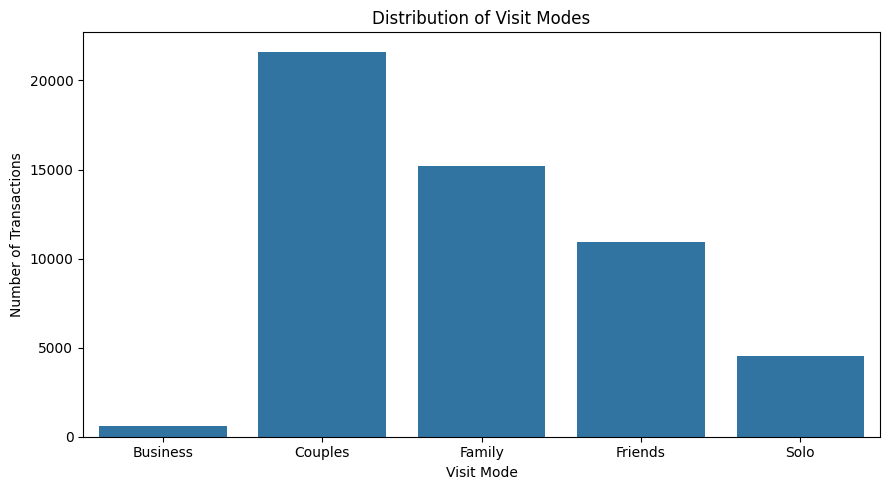

In [56]:
plt.figure(figsize=(9, 5))

plot_data = master.assign(visitmode_name=master["visitmode"].map(visitmode_labels))

sns.countplot(
    data=plot_data,
    x="visitmode_name",
    order=mode_counts.index
)

plt.title("Distribution of Visit Modes")
plt.xlabel("Visit Mode")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

In [57]:
mode_df = master.assign(visitmode_name=master["visitmode"].map(visitmode_labels))

mode_rating = pd.crosstab(
    mode_df["visitmode_name"],
    mode_df["rating"]
)

display(mode_rating)

rating,1,2,3,4,5
visitmode_name,,,,,
Business,11,9,65,227,311
Couples,601,935,3284,7323,9477
Family,322,521,1966,5106,7302
Friends,218,371,1632,3791,4933
Solo,111,199,783,1519,1913


In [58]:
mode_rating_pct = pd.crosstab(
    mode_df["visitmode_name"],
    mode_df["rating"],
    normalize="index"
) * 100

display(mode_rating_pct.round(2))

rating,1,2,3,4,5
visitmode_name,,,,,
Business,1.77,1.44,10.43,36.44,49.92
Couples,2.78,4.32,15.19,33.87,43.83
Family,2.12,3.42,12.92,33.55,47.99
Friends,1.99,3.39,14.91,34.64,45.07
Solo,2.45,4.40,17.30,33.57,42.28


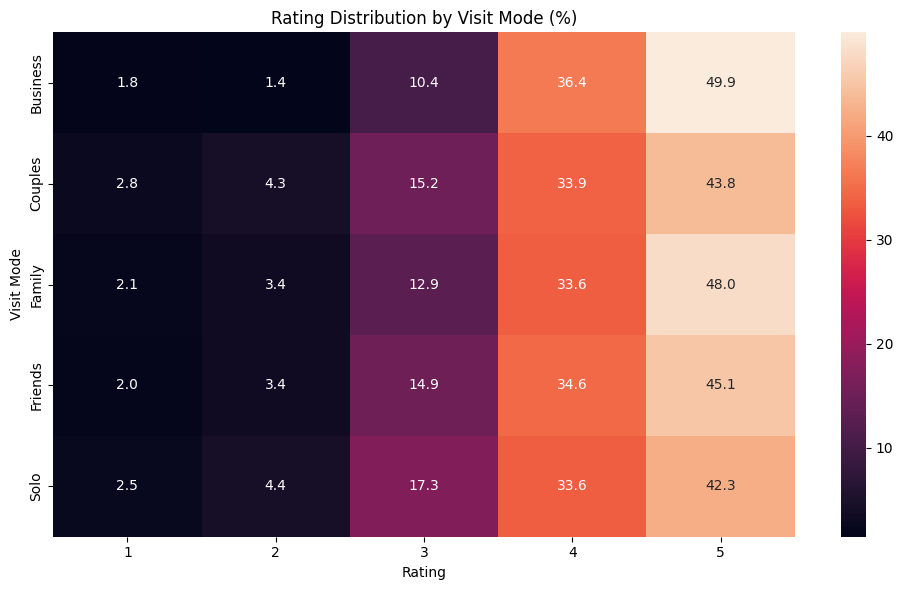

In [59]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    mode_rating_pct,
    annot=True,
    fmt=".1f"
)

plt.title("Rating Distribution by Visit Mode (%)")
plt.xlabel("Rating")
plt.ylabel("Visit Mode")

plt.tight_layout()
plt.show()

In [60]:
attraction_popularity = (
    master.groupby(
        ["attractionid", "attraction"],
        observed=True
    )
    .size()
    .reset_index(name="visit_count")
    .sort_values("visit_count", ascending=False)
)

display(attraction_popularity.head(10))

,attractionid,attraction,visit_count
2,640,Sacred Monkey Forest Sanctuary,13198
9,841,Waterbom Bali,6429
6,748,Tegalalang Rice Terrace,5815
8,824,Uluwatu Temple,3359
5,737,Tanah Lot Temple,3352
3,650,Sanur Beach,3044
4,673,Seminyak Beach,2914
0,369,Kuta Beach - Bali,2765
23,1171,Merapi Volcano,2235
7,749,Tegenungan Waterfall,2190


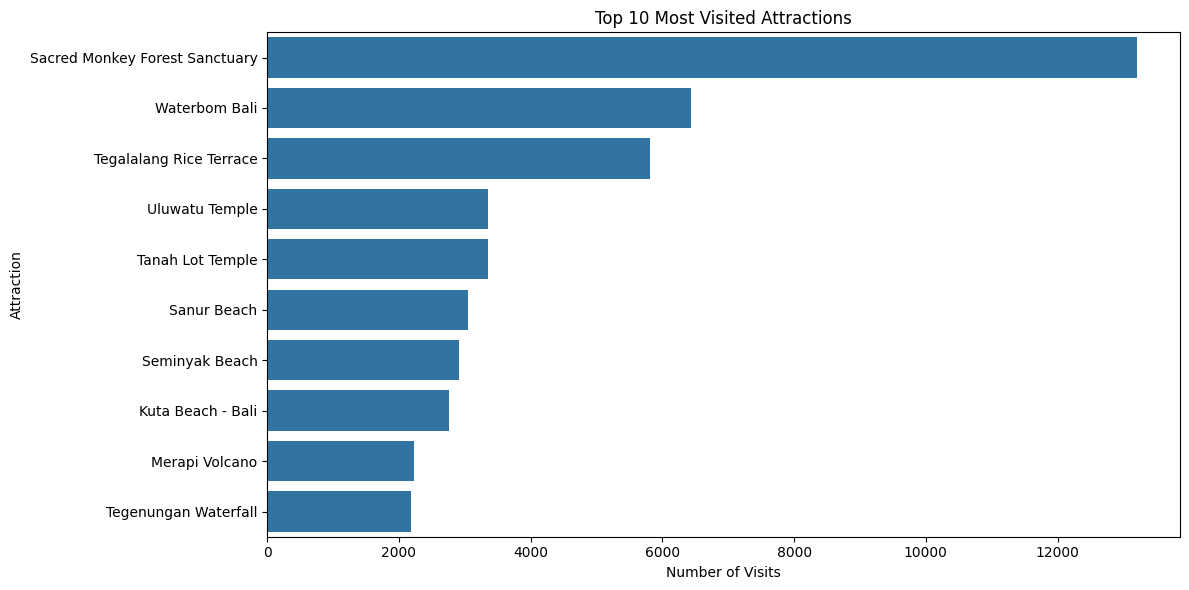

In [61]:
top10 = attraction_popularity.head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top10,
    x="visit_count",
    y="attraction"
)

plt.title("Top 10 Most Visited Attractions")
plt.xlabel("Number of Visits")
plt.ylabel("Attraction")

plt.tight_layout()
plt.show()

In [62]:
attraction_ratings = (
    master.groupby(
        ["attractionid", "attraction"],
        observed=True
    )["rating"]
    .agg(
        visit_count="count",
        average_rating="mean"
    )
    .reset_index()
    .sort_values(
        "average_rating",
        ascending=False
    )
)

display(attraction_ratings)

,attractionid,attraction,visit_count,average_rating
17,947,Mount Semeru Volcano,83,4.698795
9,841,Waterbom Bali,6429,4.646601
11,888,Bromo Tengger Semeru National Park,381,4.611549
15,928,Khayangan Reflexology & Massage,28,4.571429
20,1133,Jomblang Cave,135,4.503704
14,920,Jodipan Colorful Village,44,4.318182
1,481,Nusa Dua Beach,2104,4.275665
2,640,Sacred Monkey Forest Sanctuary,13198,4.267086
27,1278,Ullen Sentalu Museum,978,4.256646
8,824,Uluwatu Temple,3359,4.219411


In [63]:
type_analysis = (
    master.groupby(
        "attractiontype",
        observed=True
    )["rating"]
    .agg(
        visit_count="count",
        average_rating="mean"
    )
    .reset_index()
    .sort_values(
        "average_rating",
        ascending=False
    )
)

display(type_analysis)

,attractiontype,visit_count,average_rating
15,Water Parks,6429,4.646601
12,Spas,28,4.571429
3,Caverns & Caves,135,4.503704
7,National Parks,511,4.416830
9,Neighborhoods,44,4.318182
8,Nature & Wildlife Areas,13251,4.266848
6,History Museums,978,4.256646
11,Religious Sites,6711,4.207123
1,Ballets,377,4.180371
10,Points of Interest & Landmarks,6252,4.131158


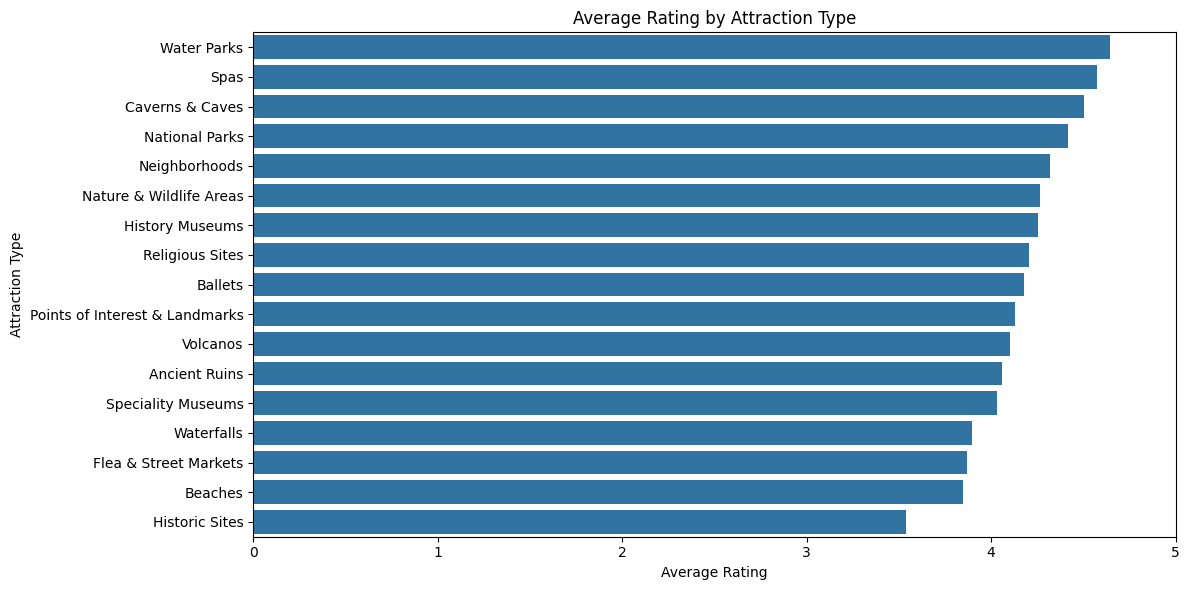

In [64]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=type_analysis,
    x="average_rating",
    y="attractiontype"
)

plt.title("Average Rating by Attraction Type")
plt.xlabel("Average Rating")
plt.ylabel("Attraction Type")
plt.xlim(0, 5)

plt.tight_layout()
plt.show()

In [65]:
yearly = (
    master.groupby("visityear")
    .agg(
        visits=("transactionid", "count"),
        average_rating=("rating", "mean")
    )
    .reset_index()
)

display(yearly)

,visityear,visits,average_rating
0,2013,2983,4.166611
1,2014,4808,4.178245
2,2015,8687,4.209739
3,2016,12823,4.171957
4,2017,9444,4.076768
5,2018,7461,4.065809
6,2019,5913,4.251818
7,2020,529,4.296786
8,2021,35,4.542857
9,2022,247,4.344130


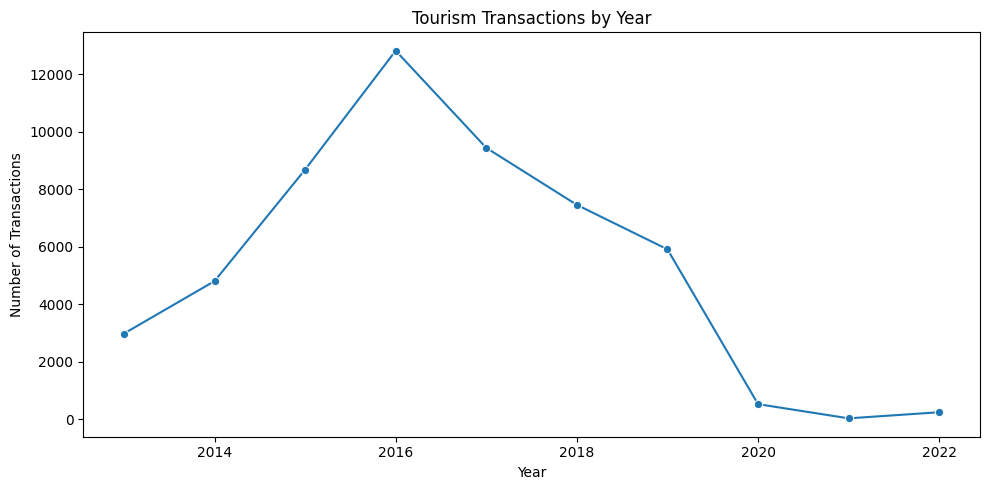

In [66]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=yearly,
    x="visityear",
    y="visits",
    marker="o"
)

plt.title("Tourism Transactions by Year")
plt.xlabel("Year")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

In [67]:
monthly = (
    master.groupby("visitmonth")
    .agg(
        visits=("transactionid", "count"),
        average_rating=("rating", "mean")
    )
    .reset_index()
)

display(monthly)

,visitmonth,visits,average_rating
0,1,4458,4.119336
1,2,3671,4.103786
2,3,3772,4.101803
3,4,4445,4.157930
4,5,4316,4.153614
5,6,4361,4.174501
6,7,4861,4.147089
7,8,5026,4.178074
8,9,4917,4.233476
9,10,4715,4.223754


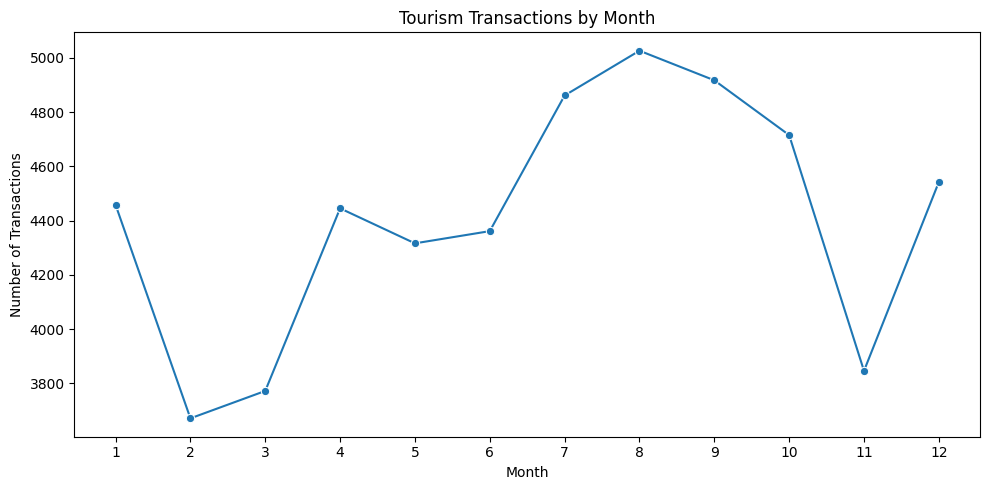

In [68]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=monthly,
    x="visitmonth",
    y="visits",
    marker="o"
)

plt.title("Tourism Transactions by Month")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")
plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

In [69]:
country_analysis = (
    master.groupby(
        "user_country",
        observed=True
    )
    .agg(
        visitors=("userid", "nunique"),
        transactions=("transactionid", "count"),
        average_rating=("rating", "mean")
    )
    .reset_index()
    .sort_values(
        "transactions",
        ascending=False
    )
)

display(country_analysis.head(15))

,user_country,visitors,transactions,average_rating
7,Australia,8848,13322,4.219712
144,United Kingdom,4062,6722,4.164088
145,United States,3799,6261,4.160837
62,Indonesia,2889,4842,4.265386
122,Singapore,1815,2807,4.027075
61,India,1627,2543,4.208022
81,Malaysia,919,1581,4.029096
27,Canada,916,1486,4.186406
100,New Zealand,959,1479,4.148749
98,Netherlands,570,859,3.910361


In [70]:
region_analysis = (
    master.groupby(
        "user_region",
        observed=True
    )
    .agg(
        visitors=("userid", "nunique"),
        transactions=("transactionid", "count"),
        average_rating=("rating", "mean")
    )
    .reset_index()
    .sort_values(
        "transactions",
        ascending=False
    )
)

display(region_analysis)

,user_region,visitors,transactions,average_rating
1,Australia,8848,13322,4.219712
17,South East Asia,6387,10392,4.134527
21,Western Europe,5275,8534,4.123272
12,Northern America,4788,7847,4.167580
16,South Asia,1858,2874,4.218859
6,Central Europe,1421,2309,4.107839
14,Oceania,989,1530,4.149020
10,Middle East,835,1266,4.242496
8,East Asia,718,1121,4.094558
19,Southern Europe,637,990,4.098990


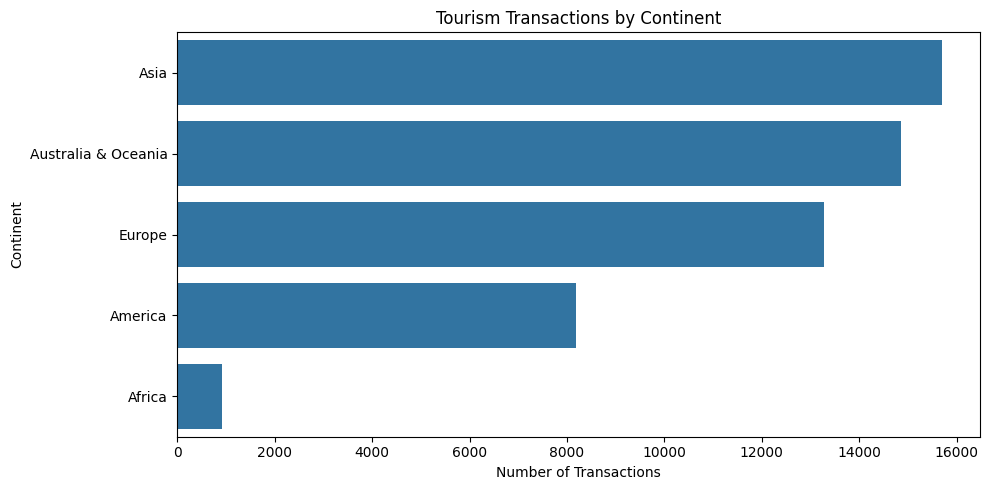

In [71]:
plt.figure(figsize=(10, 5))

continent_analysis = (
    master.groupby("user_continent", observed=True)
    .agg(
        visitors=("userid", "nunique"),
        transactions=("transactionid", "count"),
        average_rating=("rating", "mean")
    )
    .reset_index()
    .sort_values("transactions", ascending=False)
)

sns.barplot(
    data=continent_analysis,
    x="transactions",
    y="user_continent",
    order=continent_analysis["user_continent"]
)

plt.title("Tourism Transactions by Continent")
plt.xlabel("Number of Transactions")
plt.ylabel("Continent")

plt.tight_layout()
plt.show()

In [72]:
user_activity = (
    master.groupby("userid")
    .agg(
        transactions=("transactionid", "count"),
        attractions_visited=("attractionid", "nunique"),
        average_rating=("rating", "mean")
    )
    .reset_index()
    .sort_values(
        "transactions",
        ascending=False
    )
)

display(user_activity.head(10))

,userid,transactions,attractions_visited,average_rating
22862,60799,59,7,3.474576
32410,84842,40,6,3.750000
31896,83466,33,10,3.484848
19911,53429,25,2,4.600000
26762,70663,25,6,3.920000
7728,22099,23,9,4.739130
15448,42223,22,1,3.772727
9157,25963,22,7,4.000000
24744,65568,22,8,4.181818
16380,44574,22,1,4.227273


In [73]:
numeric_cols = [
    "visityear",
    "visitmonth",
    "rating"
]

corr = master[numeric_cols].corr()

display(corr)

,visityear,visitmonth,rating
visityear,1.000000,-0.159808,-0.006260
visitmonth,-0.159808,1.000000,0.019217
rating,-0.006260,0.019217,1.000000


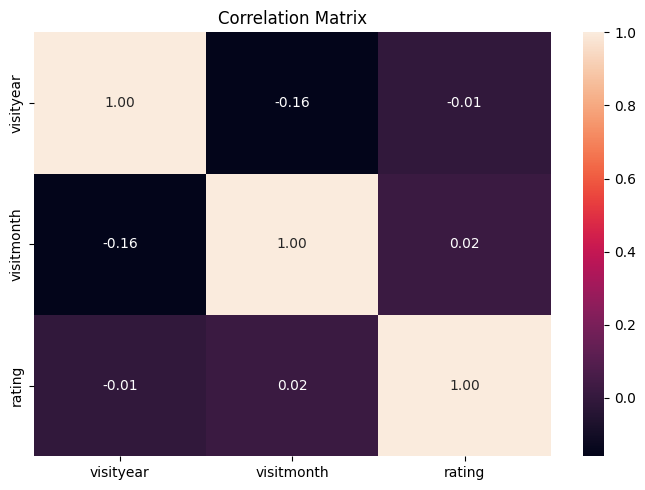

In [74]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [75]:
yearly = (
    master.groupby("visityear")
    .agg(
        visits=("transactionid", "count"),
        unique_users=("userid", "nunique"),
        average_rating=("rating", "mean")
    )
    .reset_index()
)

display(yearly)

,visityear,visits,unique_users,average_rating
0,2013,2983,2557,4.166611
1,2014,4808,3735,4.178245
2,2015,8687,6341,4.209739
3,2016,12823,8714,4.171957
4,2017,9444,6342,4.076768
5,2018,7461,5144,4.065809
6,2019,5913,4212,4.251818
7,2020,529,430,4.296786
8,2021,35,28,4.542857
9,2022,247,212,4.344130


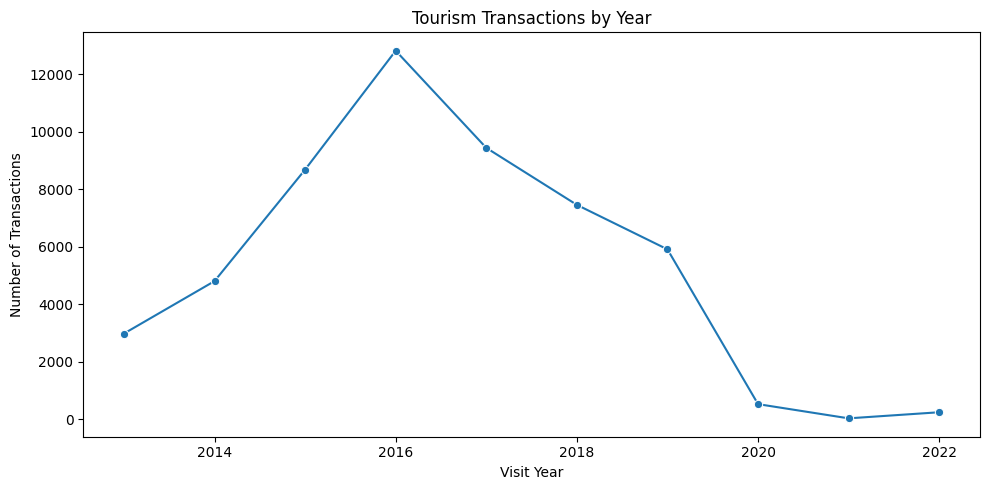

In [76]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=yearly,
    x="visityear",
    y="visits",
    marker="o"
)

plt.title("Tourism Transactions by Year")
plt.xlabel("Visit Year")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

In [77]:
monthly = (
    master.groupby("visitmonth")
    .agg(
        visits=("transactionid", "count"),
        unique_users=("userid", "nunique"),
        average_rating=("rating", "mean")
    )
    .reset_index()
)

display(monthly)

,visitmonth,visits,unique_users,average_rating
0,1,4458,3319,4.119336
1,2,3671,2733,4.103786
2,3,3772,2849,4.101803
3,4,4445,3281,4.157930
4,5,4316,3246,4.153614
5,6,4361,3284,4.174501
6,7,4861,3711,4.147089
7,8,5026,3720,4.178074
8,9,4917,3641,4.233476
9,10,4715,3498,4.223754


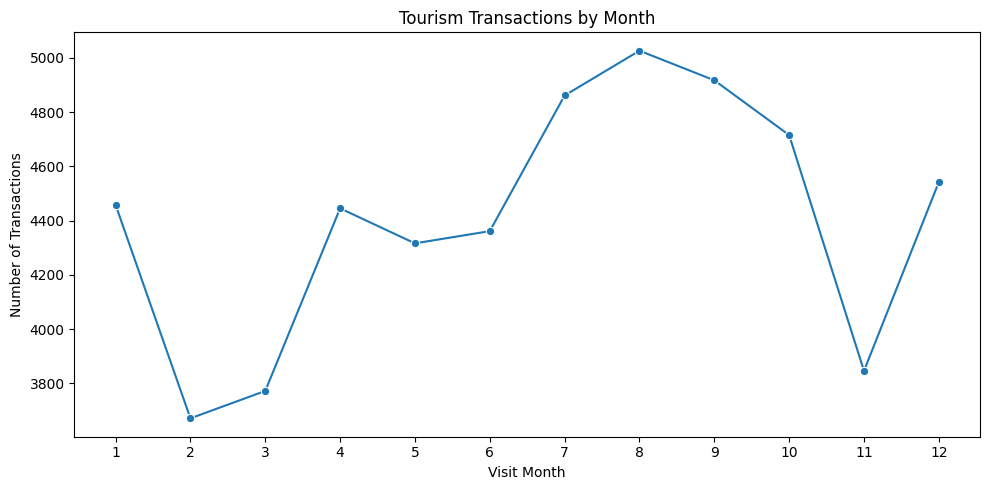

In [78]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=monthly,
    x="visitmonth",
    y="visits",
    marker="o"
)

plt.title("Tourism Transactions by Month")
plt.xlabel("Visit Month")
plt.ylabel("Number of Transactions")
plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

In [79]:
country_analysis = (
    master.groupby("user_country", observed=True)
    .agg(
        visitors=("userid", "nunique"),
        transactions=("transactionid", "count"),
        average_rating=("rating", "mean")
    )
    .reset_index()
    .sort_values("transactions", ascending=False)
)

display(country_analysis.head(15))

,user_country,visitors,transactions,average_rating
7,Australia,8848,13322,4.219712
144,United Kingdom,4062,6722,4.164088
145,United States,3799,6261,4.160837
62,Indonesia,2889,4842,4.265386
122,Singapore,1815,2807,4.027075
61,India,1627,2543,4.208022
81,Malaysia,919,1581,4.029096
27,Canada,916,1486,4.186406
100,New Zealand,959,1479,4.148749
98,Netherlands,570,859,3.910361


In [80]:
region_analysis = (
    master.groupby("user_region", observed=True)
    .agg(
        visitors=("userid", "nunique"),
        transactions=("transactionid", "count"),
        average_rating=("rating", "mean")
    )
    .reset_index()
    .sort_values("transactions", ascending=False)
)

display(region_analysis)

,user_region,visitors,transactions,average_rating
1,Australia,8848,13322,4.219712
17,South East Asia,6387,10392,4.134527
21,Western Europe,5275,8534,4.123272
12,Northern America,4788,7847,4.167580
16,South Asia,1858,2874,4.218859
6,Central Europe,1421,2309,4.107839
14,Oceania,989,1530,4.149020
10,Middle East,835,1266,4.242496
8,East Asia,718,1121,4.094558
19,Southern Europe,637,990,4.098990


In [81]:
continent_analysis = (
    master.groupby("user_continent", observed=True)
    .agg(
        visitors=("userid", "nunique"),
        transactions=("transactionid", "count"),
        average_rating=("rating", "mean")
    )
    .reset_index()
    .sort_values("transactions", ascending=False)
)

display(continent_analysis)

,user_continent,visitors,transactions,average_rating
2,Asia,9822,15693,4.155738
3,Australia & Oceania,9837,14852,4.212429
4,Europe,8260,13278,4.100090
1,America,5018,8187,4.163430
0,Africa,593,920,4.088043


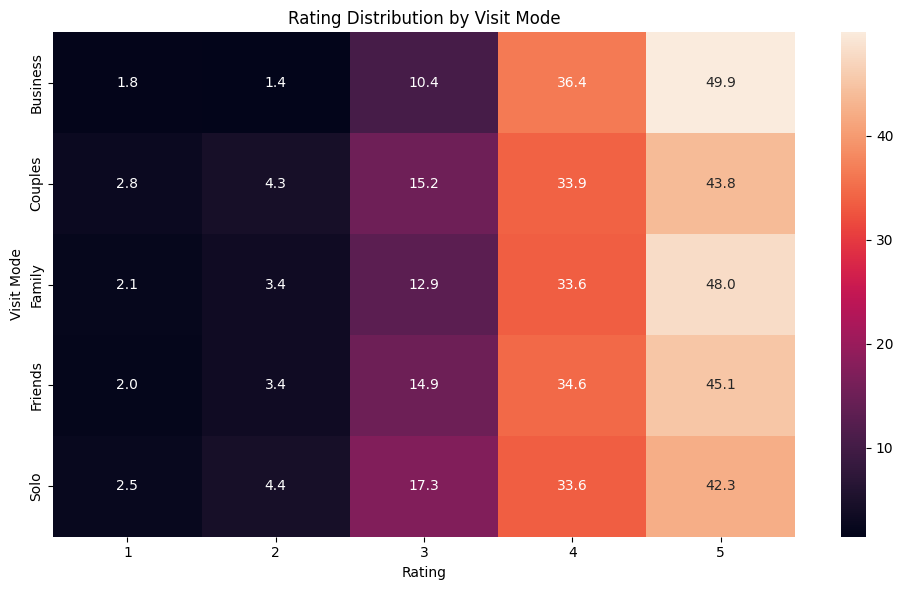

In [82]:
mode_rating_pct = pd.crosstab(
    mode_df["visitmode_name"],
    mode_df["rating"],
    normalize="index"
) * 100

plt.figure(figsize=(10, 6))

sns.heatmap(
    mode_rating_pct,
    annot=True,
    fmt=".1f"
)

plt.title("Rating Distribution by Visit Mode")
plt.xlabel("Rating")
plt.ylabel("Visit Mode")

plt.tight_layout()
plt.show()

In [83]:
attraction_analysis = (
    master.groupby(
        ["attractionid", "attraction"],
        observed=True
    )
    .agg(
        visits=("transactionid", "count"),
        average_rating=("rating", "mean")
    )
    .reset_index()
)

display(
    attraction_analysis.sort_values(
        "visits",
        ascending=False
    )
)

,attractionid,attraction,visits,average_rating
2,640,Sacred Monkey Forest Sanctuary,13198,4.267086
9,841,Waterbom Bali,6429,4.646601
6,748,Tegalalang Rice Terrace,5815,4.157524
8,824,Uluwatu Temple,3359,4.219411
5,737,Tanah Lot Temple,3352,4.194809
3,650,Sanur Beach,3044,3.976347
4,673,Seminyak Beach,2914,3.800618
0,369,Kuta Beach - Bali,2765,3.415190
23,1171,Merapi Volcano,2235,4.079195
7,749,Tegenungan Waterfall,2190,3.895434


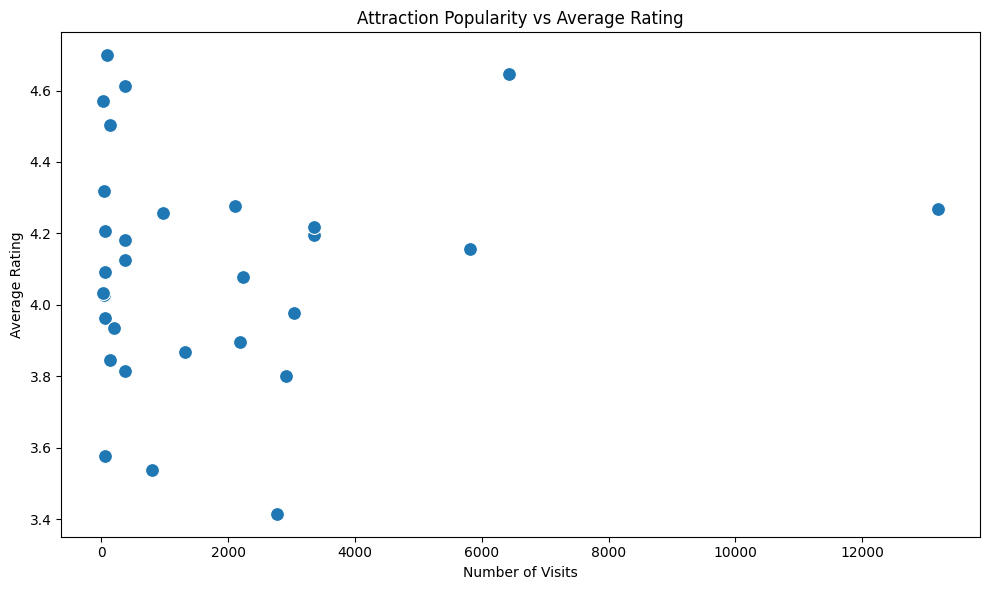

In [84]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=attraction_analysis,
    x="visits",
    y="average_rating",
    s=100
)

plt.title("Attraction Popularity vs Average Rating")
plt.xlabel("Number of Visits")
plt.ylabel("Average Rating")

plt.tight_layout()
plt.show()

In [85]:
import os

os.makedirs("../reports/eda", exist_ok=True)

rating_counts.to_csv(
    "../reports/eda/rating_distribution.csv"
)

mode_counts.to_csv(
    "../reports/eda/visit_mode_distribution.csv"
)

attraction_popularity.to_csv(
    "../reports/eda/attraction_popularity.csv",
    index=False
)

attraction_ratings.to_csv(
    "../reports/eda/attraction_ratings.csv",
    index=False
)

type_analysis.to_csv(
    "../reports/eda/attraction_type_analysis.csv",
    index=False
)

print("✅ EDA summary tables saved.")

✅ EDA summary tables saved.
